In [1]:
import os, glob, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
from itertools import combinations
from scipy.spatial.distance import pdist, squareform
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap


dates={"CW1A": "2024-07-25", "CW2A": "2024-08-01", "CW3A": "2024-08-07",
 "EXPUPS1A": "2024-07-25", "EXPUPS2A": "2024-08-01", "EXPUPS3A": "2024-08-07",
 "EXPMDS1B": "2024-07-25", "EXPMDS2B": "2024-08-01", 
 "EXPDWS1C": "2024-07-25", "EXPDWS2C": "2024-08-01", "EXPDWS3C": "2024-08-07",
 "PETUPS1A": "2024-07-25", "PETUPS2A": "2024-08-01", "PETUPS3A": "2024-08-07",
 
       "PETDWS2B": "2024-08-01", 
       "PETDWS2C": "2024-08-01", 
       
 "MBUPS1A": "2024-07-25", "MBUPS2A": "2024-08-01", "MBUPS3A": "2024-08-07",
 "MBMDS1B": "2024-07-25", "MBMDS2B": "2024-08-01", "MBMDS3B": "2024-08-07",
 "MBDWS1C": "2024-07-25", "MBDDWS2C": "2024-08-01", "MBDWS3C": "2024-08-07",
 "AJBUPS1A": "2024-07-25", "AJBUPS2A": "2024-08-01", "AJBUPS3A": "2024-08-07",
  "AJBMDS2B": "2024-08-01", "AJBMDS3B": "2024-08-07",
 "AJBDWS1C": "2024-07-25", "AJBDWS2C": "2024-08-01", "AJBDWS3C": "2024-08-07",
 "AJA1A": "2024-07-25", "AJA2A": "2024-08-01", "AJA3A": "2024-08-07"}

MT=[]
for f in glob.glob("*EsViritu.detected_virus.info.tsv"):
    df=pd.read_csv(f, sep="\t")
    MT.append(df)

MT=pd.concat(MT)

## https://www.nature.com/articles/s41467-023-42064-1#Sec8
# MT.to_csv("Virome_abundance.tsv", sep="\t")

print(len(MT["family"].unique()))
print(len(MT["genus"].unique()))
print(len(MT["species"].unique()))

MT["Cov_perc"] = MT["covered_bases"] / MT["Asm_length"] * 100

spec_count = MT[MT["Cov_perc"] >= 50].groupby("sample_ID")["subspecies"].nunique().reset_index(name="total_species").sort_values("total_species", ascending=False)

phage=MT.copy()
MT = MT.drop(columns=['kingdom', 'phylum', 'tclass', 'order','Segment', 'Assembly'], errors='ignore')
check=MT.copy()
MT=MT[MT["covered_bases"]>=1000]

print()
print(len(MT["family"].unique()))
print(len(MT["genus"].unique()))
print(len(MT["species"].unique()))


filtered_spec_count = MT[MT["Cov_perc"] >= 50].groupby("sample_ID")["subspecies"].nunique().reset_index(name="filtered_species").sort_values("filtered_species", ascending=False)


MT["dates"]=MT["sample_ID"].str.replace("_", "").map(dates)

26
62
136

11
18
38


In [6]:
PPdf=pha
len(PPdf)

28

In [3]:
ss = check.groupby("sample_ID", as_index=False)["read_count"].sum()
viral_reads_dict=dict(zip(ss["sample_ID"], ss["read_count"]))

In [4]:
for pat in ['Adenoviridae', 'Astroviridae', 'Picornaviridae', 'Caliciviridae', 'Parvoviridae', 'Polyomaviridae', 'Orthoherpesviridae']:
    sdf=check[check["family"].str.contains(pat)]
    ss = sdf.groupby("sample_ID", as_index=False)["read_count"].sum()
    ss["total"]=ss["sample_ID"].map(viral_reads_dict)
    ss["%"]=(ss["read_count"]/ss["total"])*100
    print(pat, ss["%"].mean())
   

Adenoviridae 38.5544496838866
Astroviridae 17.1504247734071
Picornaviridae 13.622905165095279
Caliciviridae 7.1225336986822745
Parvoviridae 3.8625170414349137
Polyomaviridae 1.5872106411294034
Orthoherpesviridae 5.239734969184746


In [5]:
check[check["Name"].str.contains("fluenz")]

,sample_ID,Name,description,Length,Accession,Asm_length,family,genus,species,subspecies,RPKMF,read_count,covered_bases,mean_coverage,avg_read_identity,Pi,filtered_reads_in_sample,Cov_perc
21,MB_UPS_2A,Influenza B virus (B/Rochester/0093/2013),Influenza B virus (B/Rochester/0093/2013) segm...,1549,KX351454.1,15617,f__Orthomyxoviridae,g__Betainfluenzavirus,s__Betainfluenzavirus influenzae,t__unclassified_Betainfluenzavirus influenzae,0.247511,4,129,0.315042,0.995902,0.0,10433106,0.826023


In [6]:
check[check["Name"].str.contains("syncytial")]

,sample_ID,Name,description,Length,Accession,Asm_length,family,genus,species,subspecies,RPKMF,read_count,covered_bases,mean_coverage,avg_read_identity,Pi,filtered_reads_in_sample,Cov_perc


In [7]:
check[check["Name"].str.contains("hino")]

,sample_ID,Name,description,Length,Accession,Asm_length,family,genus,species,subspecies,RPKMF,read_count,covered_bases,mean_coverage,avg_read_identity,Pi,filtered_reads_in_sample,Cov_perc
44,EXP_UPS_1A,rhinovirus C23,Rhinovirus C23 strain RvC23/USA/2021/ULVLFU,7087,MZ540948.1,7087,f__Picornaviridae,g__Enterovirus,s__Rhinovirus C,t__rhinovirus C23,0.055795,2,246,0.040638,0.965278,0.000,5057956,3.471144
45,EXP_UPS_1A,rhinovirus C31,Rhinovirus C31 strain RvC31/USA/2021/SEA4HH,6989,OL638453.1,6989,f__Picornaviridae,g__Enterovirus,s__Rhinovirus C,t__rhinovirus C31,0.056577,2,205,0.041208,0.968750,0.002,5057956,2.933181
46,EXP_UPS_1A,rhinovirus C17,Rhinovirus C17 strain RvC17/USA/2019,7067,OQ116583.1,7067,f__Picornaviridae,g__Enterovirus,s__Rhinovirus C,t__rhinovirus C17,0.111905,4,245,0.081506,0.951389,0.000,5057956,3.466818
48,AJA_2A,rhinovirus A49,Rhinovirus A49 strain RvA49/USA/2021/JT49S7,7059,MZ629143.1,7059,f__Picornaviridae,g__Enterovirus,s__Rhinovirus A,t__rhinovirus A49,0.019600,2,212,0.040799,0.972222,0.000,14455490,3.003258
49,AJA_2A,Rhinovirus B,Rhinovirus B isolate BCH214,7224,GU568096.2,7224,f__Picornaviridae,g__Enterovirus,s__Rhinovirus B,t__Rhinovirus B,0.038304,4,319,0.071705,0.976135,0.002,14455490,4.415836
50,AJA_2A,rhinovirus C23,Rhinovirus C23 strain RvC23/USA/2021/ULVLFU,7087,MZ540948.1,7087,f__Picornaviridae,g__Enterovirus,s__Rhinovirus C,t__rhinovirus C23,0.019522,2,212,0.040073,0.936905,0.002,14455490,2.991393
51,MBD_DWS_2C,Rhinovirus A,Rhinovirus A strain 12N2,7100,MN749155.1,7100,f__Picornaviridae,g__Enterovirus,s__Rhinovirus A,t__Rhinovirus A,0.065823,8,275,0.161127,0.985133,0.001,17117922,3.873239
52,MBD_DWS_2C,rhinovirus B14,Rhinovirus B14 strain SC0641,7163,MN306034.1,7163,f__Picornaviridae,g__Enterovirus,s__Rhinovirus B,t__rhinovirus B14,0.065245,8,116,0.121737,0.963303,0.000,17117922,1.619433
53,MBD_DWS_2C,rhinovirus C11,Rhinovirus C11 strain RvC11/USA/2021/XB3862,7069,OM001465.1,7069,f__Picornaviridae,g__Enterovirus,s__Rhinovirus C,t__rhinovirus C11,0.132224,16,283,0.325930,0.970052,0.002,17117922,4.003395
54,MBD_DWS_2C,Rhinovirus C,Rhinovirus C,6972,KY624849.1,6972,f__Picornaviridae,g__Enterovirus,s__Rhinovirus C,t__Rhinovirus C,0.016758,2,288,0.041308,0.944444,0.000,17117922,4.130809


In [8]:
check[check["Name"].str.contains("Rota")]

,sample_ID,Name,description,Length,Accession,Asm_length,family,genus,species,subspecies,RPKMF,read_count,covered_bases,mean_coverage,avg_read_identity,Pi,filtered_reads_in_sample,Cov_perc
62,AJA_2A,Rotavirus A,Rotavirus A strain RVA/Human-wt/ZAF/3133WC/200...,1062,HQ657154.1,18513,f__Sedoreoviridae,g__Rotavirus,s__Rotavirus alphagastroenteritidis,t__G12,0.651392,10,207,1.355932,0.979167,0.000,14455490,1.118133
50,CW_3A,Rotavirus A,Rotavirus A strain RVA/Human-wt/PRY/1679SR/200...,2701,KJ412644.1,18044,f__Sedoreoviridae,g__Rotavirus,s__Rotavirus alphagastroenteritidis,t__21,0.243723,14,152,0.746390,0.994544,0.002,21267072,0.842385
63,AJA_3A,Rotavirus A,Rotavirus A strain RVA/Human-wt/PRY/407/1999/G...,3271,KJ626844.1,16720,f__Sedoreoviridae,g__Rotavirus,s__Rotavirus alphagastroenteritidis,t__3,0.206812,10,158,0.440232,0.993056,0.000,14782376,0.944976
44,MB_UPS_3A,Rotavirus G3,Rotavirus G3,494,KU243506.2,15521,f__Sedoreoviridae,g__Rotavirus,s__Rotavirus alphagastroenteritidis,t__unclassified_Rotavirus alphagastroenteritidis,1.796093,14,240,4.080972,1.000000,0.000,15778736,1.546292


In [9]:
check[check["Name"].str.contains("arecho")].sort_values("covered_bases", ascending=False)

,sample_ID,Name,description,Length,Accession,Asm_length,family,genus,species,subspecies,RPKMF,read_count,covered_bases,mean_coverage,avg_read_identity,Pi,filtered_reads_in_sample,Cov_perc
60,MBD_DWS_2C,Parechovirus A,Parechovirus A isolate B636,7318,MW476095.1,7318,f__Picornaviridae,g__Parechovirus,s__Parechovirus A,t__Parechovirus A,0.279399,35,543,0.687210,0.922817,0.002,17117922,7.420060
30,MB_UPS_2A,parechovirus A1,Human parechovirus 1 isolate 550163,7305,GQ183021.1,7305,f__Picornaviridae,g__Parechovirus,s__Parechovirus A,t__Human parechovirus 1,0.183694,14,350,0.275975,0.955853,0.003,10433106,4.791239
44,MB_MDS_1B,Parechovirus A,Parechovirus A isolate HMS,7355,MK904605.1,7355,f__Picornaviridae,g__Parechovirus,s__Parechovirus A,t__Parechovirus A,0.085013,13,206,0.181645,0.962046,0.000,20791046,2.800816
39,PET_UPS_1A,parechovirus A1,Human parechovirus 1 isolate K150-93,7319,GQ183023.1,7319,f__Picornaviridae,g__Parechovirus,s__Parechovirus A,t__Human parechovirus 1,0.053180,8,201,0.157399,0.881076,0.005,20553888,2.746277
48,AJB_DWS_3C,Parechovirus A,Parechovirus A strain USA/TN/2015-OB2038,7146,KY271948.1,7146,f__Picornaviridae,g__Parechovirus,s__Parechovirus A,t__Parechovirus A,0.049602,4,189,0.080605,0.958333,0.000,11284842,2.644836
60,MB_MDS_3B,parechovirus A1,Human parechovirus 1 isolate 450343,7290,GQ183020.1,7290,f__Picornaviridae,g__Parechovirus,s__Parechovirus A,t__Human parechovirus 1,0.067551,7,166,0.137997,0.953373,0.015,14214730,2.277092
61,MB_MDS_3B,Parechovirus A,Parechovirus A isolate LLL,7301,MK904602.1,7301,f__Picornaviridae,g__Parechovirus,s__Parechovirus A,t__Parechovirus A,0.009636,1,144,0.019723,0.937500,0.000,14214730,1.972333
36,MB_UPS_1A,Human parechovirus 6,Human parechovirus 6 isolate 71Chzj169,7166,KT879921.1,7166,f__Picornaviridae,g__Parechovirus,s__Parechovirus A,t__Human parechovirus 6,0.035448,1,144,0.020095,0.986111,0.000,3936736,2.009489
55,AJA_3A,parechovirus A1,Human parechovirus 1 isolate 252581,7278,GQ183019.1,7278,f__Picornaviridae,g__Parechovirus,s__Parechovirus A,t__Human parechovirus 1,0.018590,2,130,0.035724,0.903846,0.004,14782376,1.786205
37,MB_UPS_1A,Parechovirus A,Parechovirus A isolate HMS,7355,MK904605.1,7355,f__Picornaviridae,g__Parechovirus,s__Parechovirus A,t__Parechovirus A,0.690734,20,104,0.278858,0.968817,0.003,3936736,1.414004


In [10]:
ni=["s__Hangzhou hydrellia griseola dicistrovirus 1", "s__Tobamovirus capsici", "s__Tobamovirus mititessellati", "s__Tobamovirus tabaci",
   "s__Tobamovirus fortpiercense", "s__Tobamovirus tomatotessellati", "s__Freshwater macrophyte associated picorna-like virus 12", "s__Cripavirus mortiferum", "s__Sanya dicistrovirus 1"
   "s__Sobemovirus SCPMV", "s__Betacarmovirus hibisci", "s__Gammacarmovirus vignae", 
    's__Protoambidensovirus dipteran1', 's__Iotapapillomavirus 1', "s__Sobemovirus SCPMV", "s__Kobuvirus aichi", "s__Sanya dicistrovirus 1"]

MT=MT[(~MT["species"].isin(ni))].sort_values("covered_bases", ascending=False)

In [11]:
animal=['t__Bamboo rat kobuvirus', 't__Bat picornavirus 9', 't__Bovine kobuvirus',  't__Canine kobuvirus', 't__Canine kobuvirus 1',
       't__Norway rat hunnivirus', 't__Rocahepevirus ratti', 't__Rodent bocavirus', 't__simian adenovirus 35 (bonobo)']

In [12]:
check[((check["subspecies"].isin(animal))) & (check["covered_bases"]>=500)].sort_values("covered_bases", ascending=False)

,sample_ID,Name,description,Length,Accession,Asm_length,family,genus,species,subspecies,RPKMF,read_count,covered_bases,mean_coverage,avg_read_identity,Pi,filtered_reads_in_sample,Cov_perc
59,MBD_DWS_2C,Bovine kobuvirus,Bovine kobuvirus isolate BKV12/2021/CHN,8289,ON168740.1,8289,f__Picornaviridae,g__Kobuvirus,s__Kobuvirus bejaponia,t__Bovine kobuvirus,1.324966,188,1657,3.213415,0.919470,0.015,17117922,19.990349
32,AJB_DWS_2C,Canine kobuvirus,Canine kobuvirus isolate SMCD-59,8216,NC_034971.1,8216,f__Picornaviridae,g__Kobuvirus,s__Canine kobuvirus,t__Canine kobuvirus,0.350481,57,1585,0.944133,0.947336,0.003,19794734,19.291626
49,AJA_1A,Bat picornavirus 9,MAG: Bat picornavirus 9 isolate GX/L134.18/2022,9086,OQ363802.1,9086,f__Picornaviridae,g__unclassified_Picornaviridae,s__Bat picornavirus 9,t__Bat picornavirus 9,0.034099,25,1316,0.367819,0.975859,0.002,80692114,14.483821
25,EXP_UPS_3A,Canine kobuvirus 1,Canine kobuvirus 1 isolate DD2 polyprotein mRNA,8313,KM068048.1,8313,f__Picornaviridae,g__Kobuvirus,s__Kobuvirus aichi,t__Canine kobuvirus 1,0.226351,37,1240,0.624925,0.935029,0.000,19663496,14.916396
5,AJB_UPS_3A,Canine kobuvirus,Canine kobuvirus strain CaKoV-26,8312,MH747478.1,8312,f__Picornaviridae,g__Kobuvirus,s__Canine kobuvirus,t__Canine kobuvirus,0.175573,28,1236,0.484962,0.973214,0.001,19186460,14.870067
11,AJB_UPS_2A,Canine kobuvirus 1,Canine kobuvirus 1 isolate DD2 polyprotein mRNA,8313,KM068048.1,8313,f__Picornaviridae,g__Kobuvirus,s__Kobuvirus aichi,t__Canine kobuvirus 1,0.307078,39,1136,0.634548,0.942432,0.001,15277720,13.665343
57,MBD_DWS_2C,Bamboo rat kobuvirus,Bamboo rat kobuvirus isolate B45M02,8291,OP094599.1,8291,f__Picornaviridae,g__Kobuvirus,s__Bamboo rat kobuvirus,t__Bamboo rat kobuvirus,0.366391,52,1066,0.895791,0.907418,0.005,17117922,12.857315
41,MB_UPS_1A,Bat picornavirus 9,MAG: Bat picornavirus 9 isolate GX/L134.18/2022,9086,OQ363802.1,9086,f__Picornaviridae,g__unclassified_Picornaviridae,s__Bat picornavirus 9,t__Bat picornavirus 9,0.950539,34,970,0.479419,0.952217,0.002,3936736,10.675765
3,AJB_UPS_3A,Rocahepevirus ratti,Rocahepevirus ratti strain LA-B350,6959,KM516906.1,6959,f__Hepeviridae,g__Rocahepevirus,s__Rocahepevirus ratti,t__Rocahepevirus ratti,0.217198,29,928,0.529386,0.955192,0.001,19186460,13.335249
7,AJB_MDS_3B,Rocahepevirus ratti,Rocahepevirus ratti strain LA-B350,6959,KM516906.1,6959,f__Hepeviridae,g__Rocahepevirus,s__Rocahepevirus ratti,t__Rocahepevirus ratti,0.885710,50,900,0.956316,0.945870,0.002,8112066,12.932893


In [13]:
check[(check["subspecies"]=="t__Rocahepevirus ratti") & (check["covered_bases"]>=500)]

,sample_ID,Name,description,Length,Accession,Asm_length,family,genus,species,subspecies,RPKMF,read_count,covered_bases,mean_coverage,avg_read_identity,Pi,filtered_reads_in_sample,Cov_perc
6,AJB_MDS_3B,Rocahepevirus ratti,Rocahepevirus ratti strain Rn16-10,6946,OR500095.1,6946,f__Hepeviridae,g__Rocahepevirus,s__Rocahepevirus ratti,t__Rocahepevirus ratti,0.461431,26,767,0.515405,0.932148,0.003,8112066,11.042327
7,AJB_MDS_3B,Rocahepevirus ratti,Rocahepevirus ratti strain LA-B350,6959,KM516906.1,6959,f__Hepeviridae,g__Rocahepevirus,s__Rocahepevirus ratti,t__Rocahepevirus ratti,0.885710,50,900,0.956316,0.945870,0.002,8112066,12.932893
41,MBD_DWS_2C,Rocahepevirus ratti,Rocahepevirus ratti strain LA-B350,6959,KM516906.1,6959,f__Hepeviridae,g__Rocahepevirus,s__Rocahepevirus ratti,t__Rocahepevirus ratti,0.637993,76,876,1.483259,0.932868,0.007,17117922,12.588016
46,MB_MDS_3B,Rocahepevirus ratti,MAG: Rocahepevirus ratti isolate rat-87,6877,ON644869.1,6877,f__Hepeviridae,g__Rocahepevirus,s__Rocahepevirus ratti,t__Rocahepevirus ratti,0.245512,24,785,0.502545,0.950810,0.005,14214730,11.414861
3,AJB_UPS_3A,Rocahepevirus ratti,Rocahepevirus ratti strain LA-B350,6959,KM516906.1,6959,f__Hepeviridae,g__Rocahepevirus,s__Rocahepevirus ratti,t__Rocahepevirus ratti,0.217198,29,928,0.529386,0.955192,0.001,19186460,13.335249


In [14]:
MAGS_no_spec=["s__Salivirus sp."]
MT=MT[(~MT["subspecies"].isin(animal))]
MT=MT[(~MT["species"].isin(MAGS_no_spec))]

In [15]:
print(len(MT["family"].unique()))
print(len(MT["genus"].unique()))
print(len(MT["species"].unique()))

7
10
20


In [16]:
rn={"Sapovirus GI.2":"Sapovirus", "norovirus GI.P13 (GI.Pd)-GI.3":"Norovirus","Sapovirus Hu/Ehime643/March 2000/JP":"Sapovirus", "norovirus GII.P16-GII.2":"Norovirus","Adeno-associated virus": "adeno-associated virus 2"}

rep=MT.copy()
rep=rep[rep["Cov_perc"]>=50]
rep["subspecies"]=rep["subspecies"].str.replace("t__", "")
rep["subspecies"]=rep["subspecies"].replace(rn)
ddf=pd.DataFrame(rep["subspecies"].value_counts()).reset_index()

rn={"Human mastadenovirus F":"HAdV-F",
   "Human astrovirus ":"HAstV", 
    "Mamastrovirus 1":"HAstV-1", "adeno-associated virus 2":"AAV-2",
"Human astrovirus 7":"HAstV-7",
   "Human astrovirus 4":"HAstV-4",
   "Human astrovirus 6":"HAstV-6",
   "Human astrovirus 2":"HAstV-2",
   "Human astrovirus 1":"HAstV-1",
   "Human astrovirus 3":"HAstV-3",
   "Human astrovirus 5":"HAstV-5",
   "Human astrovirus":"HAstV-1",
      "Astrovirus MLB1":"AstV MLB1",
}

ddf["subspecies"]=ddf["subspecies"].replace(rn)
# Sum duplicate subspecies rows
ddf = ddf.groupby("subspecies", as_index=False)["count"].sum().sort_values("count", ascending=False)
ddf=ddf.rename(columns={"count":">=50%"})
ddf = ddf.groupby("subspecies", as_index=False)[">=50%"].sum()


rn={"Sapovirus GI.2":"Sapovirus", "norovirus GI.P13 (GI.Pd)-GI.3":"Norovirus",
"Sapovirus Hu/Ehime643/March 2000/JP":"Sapovirus", "norovirus GII.P16-GII.2":"Norovirus",
"Adeno-associated virus": "adeno-associated virus 2",
   "Betapolyomavirus hominis":"BK virus",
   "norovirus GII.P17-GII.17":"Norovirus",
   "Sapovirus GIV.1":"Sapovirus",
   "norovirus GII.P16-GII.13":"Norovirus",
   "norovirus GII.P21 (GII.Pb)-GII.3":"Norovirus",
   "norovirus GII.P7-GII.6":"Norovirus",
      "Astrovirus MLB1":"AstV MLB1"}

rep=MT.copy()
rep=rep[(rep["Cov_perc"]>=25)]
rep["subspecies"]=rep["subspecies"].str.replace("t__", "")
rep["subspecies"]=rep["subspecies"].replace(rn)
ddf2=pd.DataFrame(rep["subspecies"].value_counts()).reset_index()

rn={"Human mastadenovirus F":"HAdV-F",
   "Human astrovirus ":"HAstV", 
    "Mamastrovirus 1":"HAstV-1", "adeno-associated virus 2":"AAV-2",
"Human astrovirus 7":"HAstV-7",
   "Human astrovirus 4":"HAstV-4",
   "Human astrovirus 6":"HAstV-6",
   "Human astrovirus 2":"HAstV-2",
   "Human astrovirus 1":"HAstV-1",
   "Human astrovirus 3":"HAstV-3",
   "Human astrovirus 5":"HAstV-5",
   "Human astrovirus":"HAstV-1",
   "HMO Astrovirus A":"HMO AstV",  
   "Astrovirus MLB1":"AstV MLB1",
   "JC polyomavirus":"JC",
   "Astrovirus MLB1":"AstV MLB1"}

ddf2["subspecies"]=ddf2["subspecies"].replace(rn)
ddf2=ddf2.rename(columns={"count":">=25%"})

ddf2 = ddf2.groupby("subspecies", as_index=False)[">=25%"].sum()

ddf=pd.merge(ddf, ddf2, how="outer", on="subspecies")
rn = {
    "Human mastadenovirus F": "HAdV-F",
        "Human mastadenovirus A": "HAdV-A",

        "Human mastadenovirus B": "HAdV-B",
    "Human mastadenovirus C": "HAdV-C",
    "Human mastadenovirus D": "HAdV-D",

    "Human astrovirus ": "HAstV",
    "Mamastrovirus 1": "HAstV-1",
    "adeno-associated virus 2": "AAV-2",
    "Adeno-associated virus": "AAV-2",

    "Human astrovirus": "HAstV-1",
    "Human astrovirus 1": "HAstV-1",
    "Human astrovirus 2": "HAstV-2",
    "Human astrovirus 3": "HAstV-3",
    "Human astrovirus 4": "HAstV-4",
    "Human astrovirus 5": "HAstV-5",
    "Human astrovirus 6": "HAstV-6",
    "Human astrovirus 7": "HAstV-7",

    "HMO Astrovirus A": "HMO AstV",
    "Astrovirus MLB1": "AstV MLB1",

    "JC polyomavirus": "JC",
    "Betapolyomavirus hominis": "BK virus",

    "Sapovirus GI.2": "Sapovirus",
    "Sapovirus Hu/Ehime643/March 2000/JP": "Sapovirus",
    "Sapovirus GIV.1": "Sapovirus",
"Human gammaherpesvirus 4":"EBV",
    "norovirus GI.P13 (GI.Pd)-GI.3": "Norovirus",
    "Human herpesvirus 4 type 2":"EBV",
    "norovirus GII.P16-GII.2": "Norovirus",
    "norovirus GII.P17-GII.17": "Norovirus",
    "norovirus GII.P16-GII.13": "Norovirus",
    "norovirus GII.P21 (GII.Pb)-GII.3": "Norovirus",
    "norovirus GII.P7-GII.6": "Norovirus",
    'Human adenovirus 39':'HAdV-39',
    'Human adenovirus 31':'HAdV-31',

'Human adenovirus 18':'HAdV-18',
'Human adenovirus 36':'HAdV-36',
'Human adenovirus 12':'HAdV-12',
    'Human adenovirus 2':'HAdV-2',
'Salivirus NG-J1':'Salivirus A',
'Salivirus FHB':'Salivirus A',
'Sapovirus GI':'Sapovirus',
'Sapovirus Mc10':'Sapovirus',
'norovirus GII.P16-GII.3':'Norovirus',
'norovirus GII.P16-GII.1':'Norovirus',
'Poliovirus 2':'Enterovirus C',
'norovirus GI.P8-GI.8':'Norovirus',
'Sapporo virus':'Sapovirus',
'Nongkhai virus':'Sapovirus',
'Enterovirus A76':'Enterovirus A',
'norovirus GI.P7-GI.7':'Norovirus',
'Sapovirus Hu/OH08021/2008/JP':'Sapovirus',
'norovirus GIV':'Norovirus'
}



ddf

,subspecies,>=50%,>=25%
0,AAV-2,2.0,9
1,AstV MLB1,2.0,4
2,BK virus,NaN,3
3,HAdV-F,11.0,21
4,HAstV-1,11.0,14
5,HAstV-2,3.0,8
6,HAstV-3,1.0,1
7,HAstV-4,5.0,8
8,HAstV-5,1.0,1
9,HAstV-6,3.0,7


In [17]:
ddf[">=50%"].sum()

57.0

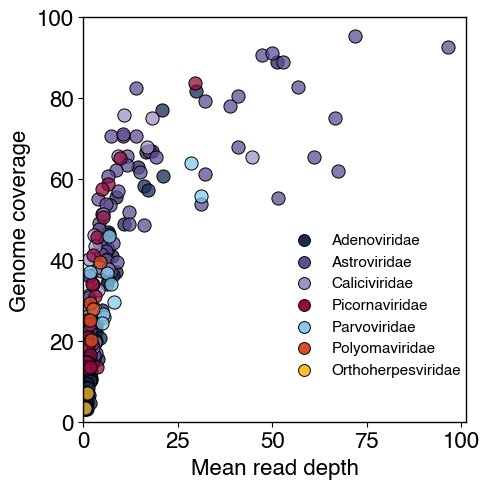

In [20]:

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Helvetica"]

cols = [ '#182b55', '#5f4e94', '#a291c7', '#900c3f', '#82cbec', '#d94f21', '#febd2b', '#9aab4b',  "#8C92AC",  "#9b2226", "#6a4c93", "#1982c4", "#8ac926",  "#ff595e",  "#FFFDD0",  "#ffca3a", "#8338ec", "#3a86ff"]

reads = MT.copy()

reads["subspecies"] = reads["subspecies"].astype(str).str.replace("t__", "", regex=False).replace(rn)

plot_df = reads.dropna(subset=["mean_coverage", "Cov_perc", "subspecies", "family"]).copy()
plot_df["family"] = plot_df["family"].str.replace("f__", "", regex=False)

family_order = plot_df["family"].value_counts().index.tolist()

family_cols = {fam: mcolors.to_rgba(cols[i % len(cols)], alpha=0.75)for i, fam in enumerate(family_order)}

fig, ax = plt.subplots(figsize=(5, 5))

for fam in family_order:
    sub = plot_df[plot_df["family"] == fam]

    ax.scatter(sub["mean_coverage"],sub["Cov_perc"],s=90,facecolors=family_cols[fam],  edgecolors="black", linewidth=0.7, label=fam)

ax.set_xlabel("Mean read depth", fontsize=16)
ax.set_ylabel("Genome coverage", fontsize=16)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

ax.tick_params(axis="x", labelsize=16, colors="black")
ax.tick_params(axis="y", labelsize=16, colors="black")

leg = ax.legend( title="", frameon=False, fontsize=11, bbox_to_anchor=(0.5, 0.5), # loc="upper left",  markerscale=0.9)

for handle in leg.legend_handles:
    fc = handle.get_facecolor()
    if len(fc) > 0:
        handle.set_facecolor([(fc[0][0], fc[0][1], fc[0][2], 1)])
    handle.set_edgecolor("black")
    handle.set_alpha(1)

for spine in ax.spines.values():
    spine.set_color("black")
    spine.set_linewidth(1)

ax.grid(False)

plt.tight_layout()


plt.show()

In [21]:
len(plot_df[(plot_df["Cov_perc"]>=50) & (plot_df["mean_coverage"]>=10) ])

42

In [22]:
plot_df["subspecies"]=plot_df["subspecies"].replace(rn)
ddf3=pd.DataFrame(plot_df[(plot_df["Cov_perc"]>=50) & (plot_df["mean_coverage"]>=10) ]["subspecies"].value_counts()).reset_index()

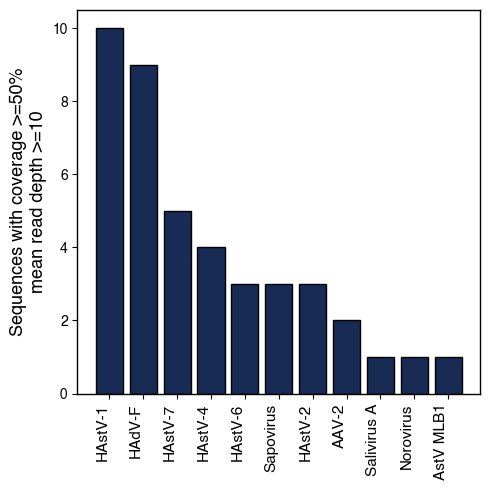

In [23]:
plot_df = ddf3.copy()
plot_df = plot_df.sort_values("count", ascending=False)
fig, ax = plt.subplots(figsize=(5, 5))

ax.bar( plot_df["subspecies"], plot_df["count"], color="#182b55", edgecolor="black", linewidth=1)
ax.set_xlabel("")
ax.set_ylabel("Sequences with coverage >=50%\nmean read depth >=10", fontsize=13)
ax.tick_params(axis="x", labelsize=11, colors="black", rotation=90)
ax.tick_params(axis="y", labelsize=10, colors="black")

for label in ax.get_xticklabels():
    label.set_ha("right")

for spine in ax.spines.values():
    spine.set_color("black")
    spine.set_linewidth(1)

ax.grid(False)

plt.tight_layout()



plt.show()

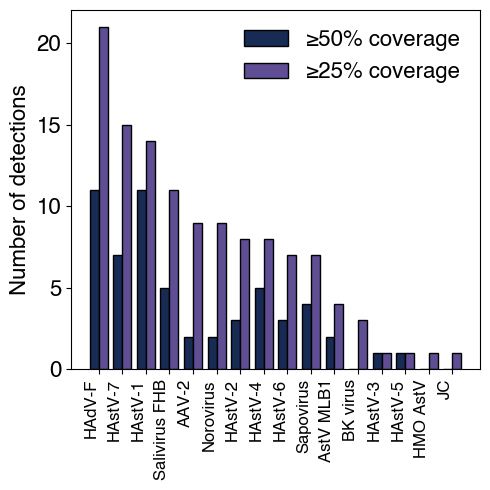

In [25]:
df = ddf.copy()
df[">=50%"] = df[">=50%"].fillna(0)
df[">=25%"] = df[">=25%"].fillna(0)
df = df.sort_values(">=25%", ascending=False)
x = np.arange(len(df))
ww = 0.38

fig, ax = plt.subplots(figsize=(5, 5))

ax.bar( x - ww / 2,df[">=50%"], ww, label="≥50% coverage",color="#182b55",edgecolor="black",linewidth=1)

ax.bar( x + ww / 2, df[">=25%"],ww,label="≥25% coverage", color="#5f4e94", edgecolor="black", linewidth=1)

ax.set_xticks(x)
ax.set_xticklabels(df["subspecies"], rotation=90, ha="right")
ax.set_xlabel("")
ax.set_ylabel("Number of detections", fontsize=16)
ax.legend(frameon=False, fontsize=16)
ax.tick_params(axis="x", labelsize=12, colors="black")
ax.tick_params(axis="y", labelsize=16, colors="black")

plt.tight_layout()


plt.show()

In [26]:
humsn_filtered_species_counts = MT[MT["Cov_perc"] >= 50].groupby("sample_ID")["subspecies"].nunique().reset_index(name="human_species").sort_values("human_species", ascending=False)

In [27]:
from functools import reduce
dfs = [species_counts, filtered_species_counts, humsn_filtered_species_counts]

cov_merged_df = reduce( lambda left, right: left.merge(right, on="sample_ID", how="inner"), dfs)

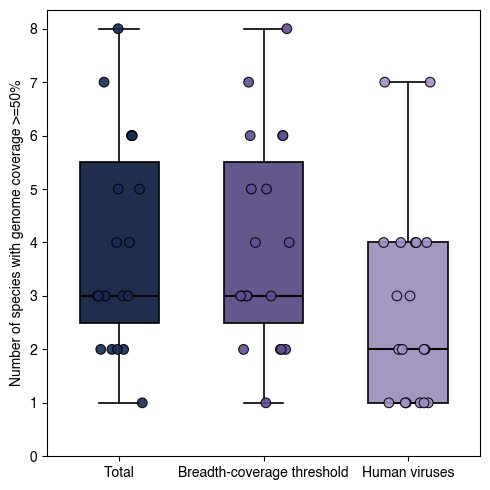

In [28]:
cols = ["total_species", "filtered_species", "human_species"]

colors = ["#182b55","#5f4e94","#a291c7","#900c3f", "#82cbec","#d94f21","#9aab4b"]
plot_df = cov_merged_df[cols].melt(var_name="category", value_name="species_count")
label_map = { "total_species": "Total", "filtered_species": "Breadth-coverage threshold", "human_species": "Human viruses"}
plot_df["category"] = plot_df["category"].map(label_map)

order = ["Total", "Breadth-coverage threshold", "Human viruses"]
fig, ax = plt.subplots(figsize=(5, 5))


sns.boxplot( data=plot_df,x="category",y="species_count",order=order,palette=colors[:3], width=0.55,showcaps=True,showfliers=False,boxprops={"edgecolor": "black", "linewidth": 1.2},whiskerprops={"color": "black", "linewidth": 1.2},capprops={"color": "black", "linewidth": 1.2},medianprops={"color": "black", "linewidth": 1.5},ax=ax)

sns.stripplot( data=plot_df,x="category",y="species_count", order=order,palette=colors[:3], size=7, jitter=0.18,edgecolor="black",linewidth=0.8,alpha=0.9,ax=ax)

ax.set_xlabel("")
ax.set_ylabel("Number of species with genome coverage >=50%")
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

In [31]:
print(cov_merged_df["total_species"].median())
print(cov_merged_df["human_species"].median())

3.0
2.0


In [30]:
##minus one for duplicate sapos
MT["Name"].unique()

<ArrowStringArray>
[              'Human mastadenovirus F',
             'human gammaherpesvirus 4',
               'Human mastadenovirus D',
                        'Salivirus FHB',
                   'Human astrovirus 4',
                   'Human astrovirus 1',
                     'Human astrovirus',
                   'Human astrovirus 6',
                      'Mamastrovirus 1',
                         'Norovirus GI',
           'Human herpesvirus 4 type 2',
                       'Sapovirus GI.2',
                   'Human astrovirus 7',
                  'Human adenovirus 39',
                  'Human adenovirus 18',
  'Sapovirus Hu/Ehime643/March 2000/JP',
                   'Human astrovirus 2',
                      'Astrovirus MLB1',
                   'Human astrovirus 3',
                      'Norovirus GII.2',
                  'Human adenovirus 31',
               'Human mastadenovirus B',
                   'Human astrovirus 5',
                  'Human adenovirus 36

In [32]:
MT["family"]=MT["family"].str.replace("f__", "")

In [33]:
tdf=pd.read_csv("read_counts_seqkit.csv")
tdf["sample"]=tdf["file"].str.replace(".AACMFLCHV.1.cleaned_bbdukclean_R1.fastq.gz", "")
rr=dict(zip(tdf["sample"], tdf["num_seqs"]))
MT["total_reads"]=MT["sample_ID"].map(rr)
# pp["RPM"]=(pp["taxReads"]/pp["total_reads"])*1000000

In [34]:
gdf = MT.groupby(['sample_ID', 'family'], as_index=False)['read_count'].sum()
top_genera = (gdf.groupby('family')['read_count'].sum().sort_values(ascending=False).head(15).index)
gdf['genus_plot'] = np.where(gdf['family'].isin(top_genera),gdf['family'],'Other')
gdf = gdf.groupby(['sample_ID', 'genus_plot'], as_index=False)['read_count'].sum()

gdf['rel_abundance'] = ( gdf.groupby('sample_ID')['read_count'].transform(lambda x: x / x.sum()))


In [35]:
MT["canal"]=[re.sub("MBD", "MB", x.split("_")[0]) for x in MT["sample_ID"]]

In [37]:
rpm_df = (MT.dropna(subset=["canal", "family"]).groupby(["canal", "family"], as_index=False).agg(read_count=("read_count", "sum"),total_reads=("total_reads", "sum")))
rpm_df["RPM"] = (rpm_df["read_count"] / rpm_df["total_reads"] * 1_000_000)

rpm_df

,canal,family,read_count,total_reads,RPM
0,AJA,Adenoviridae,7203,153786779,46.837576
1,AJA,Astroviridae,13782,186905091,73.737959
2,AJA,Caliciviridae,421,51084544,8.241240
3,AJA,Parvoviridae,182,7227745,25.180744
4,AJA,Picornaviridae,466,22010121,21.172078
5,AJB,Adenoviridae,8582,81507355,105.291111
6,AJB,Astroviridae,1466,45231889,32.410762
7,AJB,Caliciviridae,248,20983296,11.818925
8,AJB,Parvoviridae,290,5642421,51.396378
9,AJB,Picornaviridae,273,15539788,17.567807


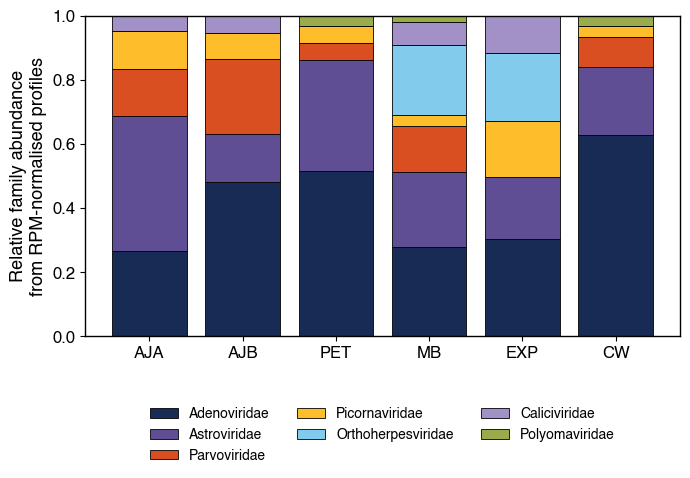

In [38]:
plot_df = rpm_df.copy()
plot_df["RPM"] = pd.to_numeric(plot_df["RPM"], errors="coerce").fillna(0)
plot_df["family"] = ( plot_df["family"].astype(str).str.replace("f__", "", regex=False))

canal_family_rpm_sum = plot_df.groupby(["canal", "family"], as_index=False)["RPM"].sum()

canal_rpm = canal_family_rpm_sum.pivot(index="canal", columns="family", values="RPM").fillna(0)
canal_rel = canal_rpm.div(canal_rpm.sum(axis=1), axis=0).fillna(0)
canal_order = ["AJA", "AJB", "PET", "MB", "EXP", "CW"]
canal_order = [c for c in canal_order if c in canal_rel.index]

canal_rel = canal_rel.loc[canal_order]
families = canal_rel.sum(axis=0).sort_values(ascending=False).index.tolist()
canal_rel = canal_rel[families]


color_dict = { "Adenoviridae": "#182b55", "Astroviridae": "#5f4e94", "Caliciviridae": "#a291c7","Coronaviridae": "#900c3f", "Herpesviridae": "#82cbec", "Orthoherpesviridae": "#82cbec", "Parvoviridae": "#d94f21", "Picornaviridae": "#febd2b","Polyomaviridae": "#9aab4b",}

extra_c = [ "#8C92AC", "#9b2226", "#6a4c93", "#1982c4",  "#8ac926","#ff595e", "#FFFDD0", "#ffca3a", "#8338ec","#3a86ff"]
color_map = color_dict.copy()
extra_idx = 0
for fam in families:
    if fam not in color_map:
        color_map[fam] = extra_c[extra_idx % len(extra_c)]
        extra_idx += 1


fig, ax = plt.subplots(figsize=(7, 5))

bottom = np.zeros(len(canal_rel))

for fam in families:
    vals = canal_rel[fam].values
    ax.bar( canal_rel.index,  vals, bottom=bottom, label=fam,color=color_map[fam], edgecolor="black",linewidth=0.6)

    bottom += vals

ax.set_xlabel("")
ax.set_ylabel("Relative family abundance\nfrom RPM-normalised profiles", fontsize=13)
ax.set_ylim(0, 1)

ax.tick_params(axis="x", labelsize=12, colors="black")
ax.tick_params(axis="y", labelsize=12, colors="black")

for spine in ax.spines.values():
    spine.set_color("black")
    spine.set_linewidth(1)

ax.legend( title="", loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=3, frameon=False,fontsize=10)

ax.grid(False)

plt.tight_layout()
plt.show()

In [39]:
rpm_df[rpm_df["family"].str.contains("Ortho")]

,canal,family,read_count,total_reads,RPM
18,EXP,Orthoherpesviridae,495,2528978,195.73124
23,MB,Orthoherpesviridae,998,7889368,126.49936


In [40]:
MT[MT["family"].str.contains("Ortho")]

,sample_ID,Name,description,Length,Accession,Asm_length,family,genus,species,subspecies,RPKMF,read_count,covered_bases,mean_coverage,avg_read_identity,Pi,filtered_reads_in_sample,Cov_perc,total_reads,canal
22,MB_UPS_3A,human gammaherpesvirus 4,Human gammaherpesvirus 4,171823,NC_007605.1,171823,Orthoherpesviridae,g__Lymphocryptovirus,s__Lymphocryptovirus humangamma4,t__Human gammaherpesvirus 4,0.36811,998,12277,0.819576,0.995531,0.001,15778736,7.145144,7889368,MB
37,EXP_UPS_1A,Human herpesvirus 4 type 2,Human herpesvirus 4,172764,NC_009334.1,172764,Orthoherpesviridae,g__Lymphocryptovirus,s__Lymphocryptovirus humangamma4,t__Human herpesvirus 4 type 2,0.56647,495,5737,0.372080,0.992755,0.004,5057956,3.320715,2528978,EXP


In [41]:
canal_rel

family,Adenoviridae,Astroviridae,Parvoviridae,Picornaviridae,Orthoherpesviridae,Caliciviridae,Polyomaviridae
canal,,,,,,,
AJA,0.267384,0.420952,0.143751,0.120866,0.000000,0.047047,0.000000
AJB,0.481915,0.148343,0.235240,0.080407,0.000000,0.054095,0.000000
PET,0.516376,0.346178,0.053178,0.051866,0.000000,0.000000,0.032403
MB,0.279871,0.233343,0.142089,0.034705,0.217112,0.072357,0.020524
EXP,0.303398,0.193688,0.000000,0.175594,0.211204,0.116117,0.000000
CW,0.626598,0.212248,0.095403,0.033950,0.000000,0.000000,0.031801


In [44]:
dates={"CW1A": "2024-07-25", "CW2A": "2024-08-01", "CW3A": "2024-08-07",
 "EXPUPS1A": "2024-07-25", "EXPUPS2A": "2024-08-01", "EXPUPS3A": "2024-08-07",
 "EXPMDS1B": "2024-07-25", "EXPMDS2B": "2024-08-01", 
 "EXPDWS1C": "2024-07-25", "EXPDWS2C": "2024-08-01", "EXPDWS3C": "2024-08-07",
 "PETUPS1A": "2024-07-25", "PETUPS2A": "2024-08-01", "PETUPS3A": "2024-08-07",
 
       "PETDWS2B": "2024-08-01", 
       "PETDWS2C": "2024-08-01", 
       
 "MBUPS1A": "2024-07-25", "MBUPS2A": "2024-08-01", "MBUPS3A": "2024-08-07",
 "MBMDS1B": "2024-07-25", "MBMDS2B": "2024-08-01", "MBMDS3B": "2024-08-07",
 "MBDWS1C": "2024-07-25", "MBDDWS2C": "2024-08-01", "MBDWS3C": "2024-08-07",
 "AJBUPS1A": "2024-07-25", "AJBUPS2A": "2024-08-01", "AJBUPS3A": "2024-08-07",
  "AJBMDS2B": "2024-08-01", "AJBMDS3B": "2024-08-07",
 "AJBDWS1C": "2024-07-25", "AJBDWS2C": "2024-08-01", "AJBDWS3C": "2024-08-07",
 "AJA1A": "2024-07-25", "AJA2A": "2024-08-01", "AJA3A": "2024-08-07"}



MT["dates"]=MT["sample_ID"].str.replace("_", "").map(dates)

gdf=MT.groupby(['sample_ID', 'family'], as_index=False)['read_count'].sum()
gdf["total_reads"]=gdf["sample_ID"].map(rr)
gdf["dates"]=gdf["sample_ID"].str.replace("_", "").map(dates)


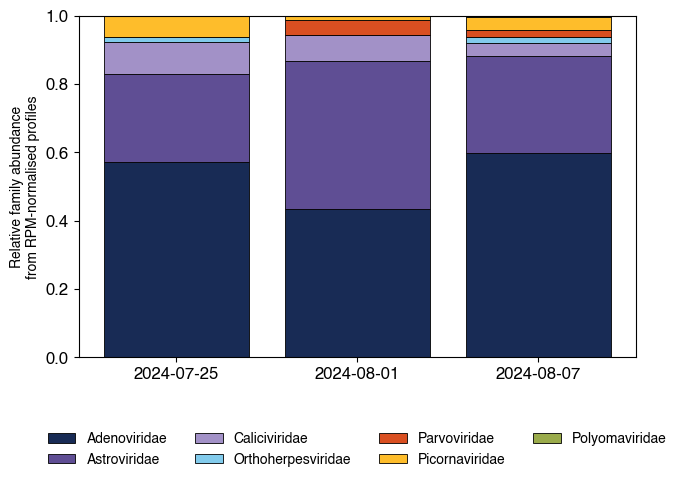

In [46]:
plot_df = gdf.copy()
plot_df["read_count"] = pd.to_numeric(plot_df["read_count"], errors="coerce").fillna(0)
plot_df["total_reads"] = pd.to_numeric(plot_df["total_reads"], errors="coerce").fillna(0)
plot_df["RPM"] = plot_df["read_count"] / plot_df["total_reads"] * 1e6
canal_family_rpm =  plot_df.groupby(["dates", "family"], as_index=False)["RPM"].sum()

canal_rpm = canal_family_rpm.pivot(index="dates", columns="family", values="RPM").fillna(0)
canal_rel = canal_rpm.div(canal_rpm.sum(axis=1), axis=0).fillna(0)
canal_order = ["2024-07-25", "2024-08-01", "2024-08-07"]
canal_order = [c for c in canal_order if c in canal_rel.index]
canal_rel = canal_rel.loc[canal_order]


color_dict = {
    "Adenoviridae": "#182b55",
    "Astroviridae": "#5f4e94",
    "Caliciviridae": "#a291c7",
    "Coronaviridae": "#900c3f",
    "Herpesviridae": "#82cbec",
    "Orthoherpesviridae": "#82cbec",
    "Parvoviridae": "#d94f21",
    "Picornaviridae": "#febd2b",
    "Polyomaviridae": "#9aab4b",
}

ext_c = [ "#8C92AC", "#9b2226",  "#6a4c93",  "#1982c4",  "#8ac926", "#ff595e",  "#FFFDD0",  "#ffca3a",  "#8338ec","#3a86ff",]

families = list(canal_rel.columns)
color_map = color_dict.copy()
extra_idx = 0
for fam in families:
    if fam not in color_map:
        color_map[fam] = ext_c[extra_idx % len(extraext_c_colors)]
        extra_idx += 1


fig, ax = plt.subplots(figsize=(7, 5))
bottom = np.zeros(len(canal_rel))

for fam in families:
    vals = canal_rel[fam].values
    ax.bar(canal_rel.index, vals,bottom=bottom, label=fam,color=color_map[fam],edgecolor="black", linewidth=0.6)
    bottom += vals

ax.set_xlabel("")
ax.set_ylabel("Relative family abundance\nfrom RPM-normalised profiles")
ax.set_ylim(0, 1)

ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", labelsize=12)

ax.legend( title="", loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=4, frameon=False)
plt.tight_layout()

plt.show()

In [47]:
from scipy.spatial.distance import pdist, squareform
import seaborn as sns

plot_df = gdf.copy()
plot_df["read_count"] = pd.to_numeric(plot_df["read_count"], errors="coerce").fillna(0)
plot_df["total_reads"] = pd.to_numeric(plot_df["total_reads"], errors="coerce").fillna(0)
plot_df["RPM"] = plot_df["read_count"] / plot_df["total_reads"] * 1e6
canal_family_rpm = plot_df.groupby(["dates", "family"], as_index=False)["RPM"].sum()
canal_rpm = canal_family_rpm.pivot(index="dates", columns="family", values="RPM").fillna(0)
canal_rel = canal_rpm.div(canal_rpm.sum(axis=1), axis=0).fillna(0)

canal_bc = pd.DataFrame(squareform(pdist(canal_rel.values, metric="braycurtis")),index=canal_rel.index,columns=canal_rel.index)

canal_bc

dates,2024-07-25,2024-08-01,2024-08-07
dates,,,
2024-07-25,0.000000,0.218304,0.081067
2024-08-01,0.218304,0.000000,0.207840
2024-08-07,0.081067,0.207840,0.000000


In [48]:
p_canal_bc = []

for c1, c2 in combinations(canal_rel.index, 2):
    p_canal_bc.append({"canal1": c1,"canal2": c2, "bray_curtis": canal_bc.loc[c1, c2]})
p_canal_bc = pd.DataFrame(p_canal_bc).sort_values("bray_curtis", ascending=False)
p_canal_bc

,canal1,canal2,bray_curtis
0,2024-07-25,2024-08-01,0.218304
2,2024-08-01,2024-08-07,0.207840
1,2024-07-25,2024-08-07,0.081067


In [49]:
MT.groupby("family")["read_count"].sum().sort_values(ascending=False).head(10)


family
Adenoviridae          94269
Astroviridae          56549
Caliciviridae          8836
Picornaviridae         4972
Parvoviridae           3470
Orthoherpesviridae     1493
Polyomaviridae          457
Name: read_count, dtype: int64

In [51]:
MT.groupby("genus")["read_count"].sum().sort_values(ascending=False).head(10)

genus
g__Mastadenovirus               94269
g__Mamastrovirus                49049
g__unclassified_Astroviridae     7500
g__Sapovirus                     6059
g__Salivirus                     4548
g__Dependoparvovirus             3470
g__Norovirus                     2777
g__Lymphocryptovirus             1493
g__Betapolyomavirus               457
g__Enterovirus                    424
Name: read_count, dtype: int64

In [52]:
astrovirus_dict = { 'Human astrovirus': 'Mamastrovirus 1','Human astrovirus 1': 'Mamastrovirus 1', 'Human astrovirus 2': 'Mamastrovirus 1', 'Human astrovirus 3': 'Mamastrovirus 1','Human astrovirus 4': 'Mamastrovirus 1', 'Human astrovirus 5': 'Mamastrovirus 1','Human astrovirus 6': 'Mamastrovirus 1','Human astrovirus 7': 'Mamastrovirus 1','Mamastrovirus 1': 'Mamastrovirus 1'}
MT['Name'] = MT['Name'].replace(astrovirus_dict)
norovirus_dict = { 'Norovirus GI': 'Norovirus', 'Norovirus GII.2': 'Norovirus', 'Norovirus GII': 'Norovirus', 'Norovirus Hu/GII.6/CHDC4073/1984/USA': 'Norovirus', 'Norovirus GII.17': 'Norovirus', 'Norovirus Hu/Texas/TCH04-577/2004/US': 'Norovirus', 'Norovirus GIV': 'Norovirus', 'Norovirus Hu/GII.3/HK71/1978/CHN': 'Norovirus', 'Norovirus GI.7': 'Norovirus',  'Norovirus GII/Hu/NL/2014/GII.21/Groningen': 'Norovirus'}
MT['Name'] = MT['Name'].replace(norovirus_dict)
sapovirus_dict = { 'Sapovirus GI.2': 'Sapovirus','Sapovirus Hu/Ehime643/March 2000/JP': 'Sapovirus','Sapovirus GIV.1': 'Sapovirus', 'Sapovirus GI': 'Sapovirus','Sapovirus Mc10': 'Sapovirus', 'Sapporo virus': 'Sapovirus','Sapovirus Hu/OH08021/2008/JP': 'Sapovirus','Sapovirus GII': 'Sapovirus','Sapovirus D1737-A/Jun2008/JPN': 'Sapovirus','Sapovirus Sapozj-9': 'Sapovirus', 'Sapovirus Mc114': 'Sapovirus', 'Sapovirus SaKaeo-15/Thailand': 'Sapovirus', 'Sapovirus Chanthaburi-74/Thailand': 'Sapovirus'}
MT['Name'] = MT['Name'].replace(sapovirus_dict)
MT['Name'] = MT['Name'].str.replace("Severe acute respiratory syndrome coronavirus 2", "SARS-2")

exx = { 'Human adenovirus 31': 'Human mastadenovirus A',"Human adenovirus 18":"Human mastadenovirus A",
"Human adenovirus 12":"Human mastadenovirus A", 
"Betapolyomavirus hominis":"BK virus", 
"Human adenovirus 2":"Human mastadenovirus C",
"Human adenovirus 36":"Human mastadenovirus D", 
"Nongkhai virus":"Sapovirus", 
"Paslahepevirus balayani": "Hepatitis E", 
"Adeno-associated virus":"AAV2",
"adeno-associated virus 2":"AAV2",
"Enterovirus A76":"Enterovirus A", "Echovirus E7":"Enterovirus B",
"Poliovirus 2":"Enterovirus C", "Poliovirus 1":"Enterovirus C", 
"Human adenovirus 39":"Human mastadenovirus D",
"Norwalk-like virus":"Norovirus",
"Coxsackievirus A16":"Enterovirus A","Coxsackievirus A19":"Enterovirus C",
    "Coxsackievirus A22":"Enterovirus C","Enterovirus B84":"Enterovirus B"
,"Enterovirus B87":"Enterovirus B",
"human gammaherpesvirus 4":"EBV",
"Human herpesvirus 4 type 2":"EBV", "Human adenovirus 3+11p":"Human mastadenovirus D",
"Astrovirus MLB1":"NC-astro", "Astrovirus MLB2":"NC-astro",
"Salivirus NG-J1":"Salivirus A", "Salivirus FHB":"Salivirus A",
"HMO Astrovirus A":"NC-astro"}
MT['Name'] = MT['Name'].replace(exx)
MT['Name'] = MT['Name'].replace({"Hepatitis E":"Hepatitis E virus"})

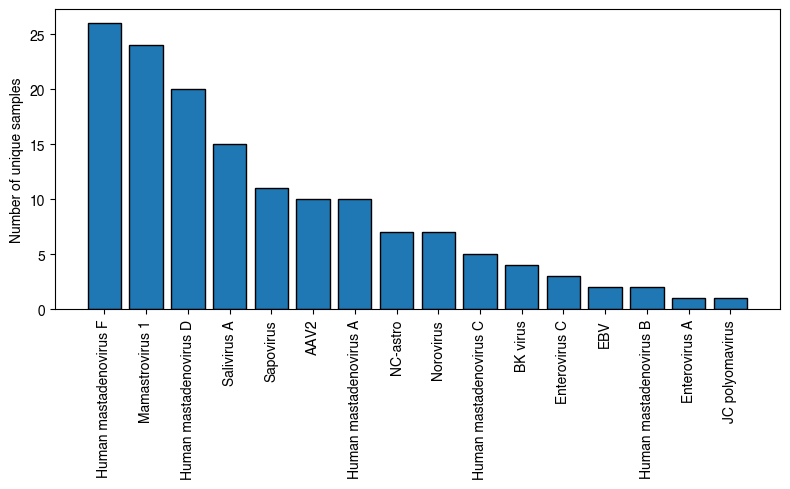

In [54]:

n_sample_counts = MT.groupby('Name')['sample_ID'].nunique().sort_values(ascending=False).reset_index(name='n_unique_sample_IDs')
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(n_sample_counts['Name'],n_sample_counts['n_unique_sample_IDs'],edgecolor='black')
ax.set_xlabel('')
ax.set_ylabel('Number of unique samples')
ax.set_xticks(range(len(n_sample_counts)))
ax.set_xticklabels( n_sample_counts['Name'],rotation=90, ha='center')

plt.tight_layout()
plt.show()

In [55]:
noro = MT[MT["Name"].str.contains("Noro", na=False)].copy()

In [56]:
noro[0:10]

,sample_ID,Name,description,Length,Accession,Asm_length,family,genus,species,subspecies,...,read_count,covered_bases,mean_coverage,avg_read_identity,Pi,filtered_reads_in_sample,Cov_perc,total_reads,canal,dates
8,MB_UPS_3A,Norovirus,Norovirus GI Hu/IN/2018/GI.3[P13]/NICED-RV-791...,7815,LC769711.1,7815,Caliciviridae,g__Norovirus,s__Norovirus norwalkense,t__norovirus GI.P13 (GI.Pd)-GI.3,...,601,5918,10.814971,0.968649,0.003,15778736,75.726168,7889368,MB,2024-08-07
7,MB_UPS_3A,Norovirus,Norovirus GII.2 strain Env/CHN/2016/GII.P16-GI...,7536,NC_039476.1,7536,Caliciviridae,g__Norovirus,s__Norovirus norwalkense,t__norovirus GII.P16-GII.2,...,281,3867,5.305732,0.959760,0.002,15778736,51.313694,7889368,MB,2024-08-07
5,MB_UPS_2A,Norovirus,Norovirus GII.2 strain Env/CHN/2016/GII.P16-GI...,7536,NC_039476.1,7536,Caliciviridae,g__Norovirus,s__Norovirus norwalkense,t__norovirus GII.P16-GII.2,...,145,3476,2.754644,0.958519,0.001,10433106,46.125265,5216553,MB,2024-08-01
17,MBD_DWS_2C,Norovirus,Norovirus GI Hu/IN/2018/GI.3[P13]/NICED-RV-791...,7815,LC769711.1,7815,Caliciviridae,g__Norovirus,s__Norovirus norwalkense,t__norovirus GI.P13 (GI.Pd)-GI.3,...,175,3387,3.108765,0.961207,0.003,17117922,43.339731,8558961,MB,2024-08-01
19,EXP_UPS_1A,Norovirus,Norovirus GII strain Hu/GII.P16-GII.13/RUS/Nov...,7510,MG892908.3,7510,Caliciviridae,g__Norovirus,s__Norovirus norwalkense,t__norovirus GII.P16-GII.13,...,349,2835,6.596272,0.965709,0.002,5057956,37.749667,2528978,EXP,2024-07-25
18,EXP_UPS_1A,Norovirus,Norovirus Hu/GII.6/CHDC4073/1984/USA,7534,JX846927.1,7534,Caliciviridae,g__Norovirus,s__Norovirus norwalkense,t__norovirus GII.P7-GII.6,...,208,2449,3.870852,0.941008,0.008,5057956,32.505973,2528978,EXP,2024-07-25
15,MBD_DWS_2C,Norovirus,Norovirus GII.17,7556,NC_039475.1,7556,Caliciviridae,g__Norovirus,s__Norovirus norwalkense,t__norovirus GII.P17-GII.17,...,124,2111,2.305850,0.938212,0.003,17117922,27.938062,8558961,MB,2024-08-01
6,MB_UPS_3A,Norovirus,Norovirus GII.17,7556,NC_039475.1,7556,Caliciviridae,g__Norovirus,s__Norovirus norwalkense,t__norovirus GII.P17-GII.17,...,62,2080,1.169137,0.925259,0.001,15778736,27.527792,7889368,MB,2024-08-07
17,EXP_UPS_1A,Norovirus,Norovirus Hu/Texas/TCH04-577/2004/US genomic RNA,7627,AB365435.1,7627,Caliciviridae,g__Norovirus,s__Norovirus norwalkense,t__norovirus GII.P21 (GII.Pb)-GII.3,...,310,1972,5.543726,0.905921,0.001,5057956,25.855513,2528978,EXP,2024-07-25
24,AJA_3A,Norovirus,Norovirus GII strain Hu/GII.P16-GII.3/RUS/Novo...,7569,MG892946.3,7569,Caliciviridae,g__Norovirus,s__Norovirus norwalkense,t__norovirus GII.P16-GII.3,...,55,1421,1.022592,0.942333,0.003,14782376,18.773946,7391188,AJA,2024-08-07


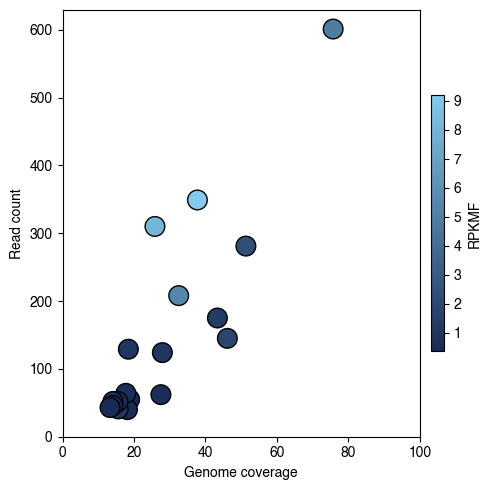

In [58]:
cmap = LinearSegmentedColormap.from_list( "custom_blue_cyan",["#182b55", "#82cbec"])
noro = MT[MT["Name"].str.contains("Noro", na=False)].copy()
noro["Geno"] = noro["Name"]
noro["Cov_perc"] = noro["covered_bases"] / noro["Asm_length"] * 100
fig, ax = plt.subplots(figsize=(5, 5))

scatter = ax.scatter(noro["Cov_perc"], noro["read_count"], s=200, c=noro["RPKMF"],cmap=cmap,edgecolor="black",linewidth=1,alpha=1)
ax.set_xlabel("Genome coverage")
ax.set_ylabel("Read count")

ax.set_ylim(0)
ax.set_xlim(0, 100)

cbar = plt.colorbar(scatter, ax=ax, shrink=0.6, fraction=0.045, pad=0.03)
cbar.set_label("RPKMF")

plt.tight_layout()

plt.show()

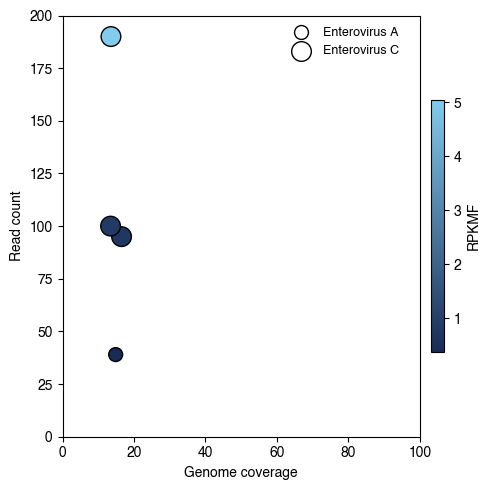

In [59]:
entero = MT[MT["Name"].str.contains("Entero", na=False)].copy()
entero["Geno"] = entero["Name"]
entero["Cov_perc"] = entero["covered_bases"] / entero["Asm_length"] * 100
ns = sorted(entero["Name"].dropna().unique())
size_values = np.linspace(100, 200, len(ns)) 
size_dict = dict(zip(ns, size_values))
entero["dot_size"] = entero["Name"].map(size_dict)

fig, ax = plt.subplots(figsize=(5, 5))

scatter = ax.scatter( entero["Cov_perc"],entero["read_count"],s=entero["dot_size"],c=entero["RPKMF"],cmap=cmap,edgecolor="black",linewidth=1,alpha=1)

ax.set_xlabel("Genome coverage")
ax.set_ylabel("Read count")
ax.set_ylim(0, 200)
ax.set_xlim(0, 100)

cbar = plt.colorbar(scatter, ax=ax, shrink=0.6, fraction=0.045, pad=0.03)
cbar.set_label("RPKMF")

size_handles = [ax.scatter([],[],s=size_dict[name],color="white",edgecolor="black",linewidth=1,label=name) for name in ns]

ax.legend( handles=size_handles, title="",  frameon=False,  bbox_to_anchor=(0.6, 1), loc="upper left", fontsize=9, title_fontsize=10)

plt.tight_layout()

plt.show()

In [60]:
entero

,sample_ID,Name,description,Length,Accession,Asm_length,family,genus,species,subspecies,...,mean_coverage,avg_read_identity,Pi,filtered_reads_in_sample,Cov_perc,total_reads,canal,dates,Geno,dot_size
50,MBD_DWS_2C,Enterovirus C,Poliovirus 2 strain NIE0911391,7440,JX275294.2,7440,Picornaviridae,g__Enterovirus,s__Enterovirus C,t__Poliovirus 2,...,1.822581,0.922091,0.007,17117922,16.518817,8558961,MB,2024-08-01,Enterovirus C,200.0
52,MB_MDS_3B,Enterovirus A,UNVERIFIED: Enterovirus A76 strain KS-XMLH83FX...,7439,ON646240.1,7439,Picornaviridae,g__Enterovirus,s__Enterovirus A,t__Enterovirus A76,...,0.729265,0.914610,0.002,14214730,14.867590,7107365,MB,2024-08-07,Enterovirus A,100.0
43,EXP_UPS_1A,Enterovirus C,Poliovirus 2 strain NIE1011694,7438,JX275345.2,7438,Picornaviridae,g__Enterovirus,s__Enterovirus C,t__Poliovirus 2,...,3.616429,0.915804,0.017,5057956,13.552030,2528978,EXP,2024-07-25,Enterovirus C,200.0
29,MB_UPS_3A,Enterovirus C,Poliovirus 2 strain NIE1011686,7440,JX275338.2,7440,Picornaviridae,g__Enterovirus,s__Enterovirus C,t__Poliovirus 2,...,1.874731,0.905929,0.012,15778736,13.440860,7889368,MB,2024-08-07,Enterovirus C,200.0


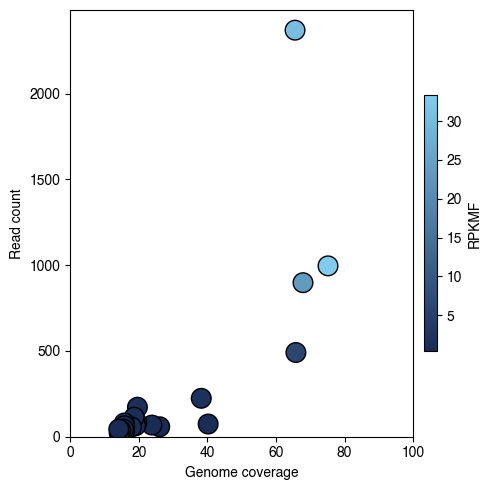

In [61]:
Sapo = MT[MT["Name"].str.contains("Sap", na=False)].copy()
Sapo["Geno"] = Sapo["Name"]
Sapo["Cov_perc"] = Sapo["covered_bases"] / Sapo["Asm_length"] * 100

fig, ax = plt.subplots(figsize=(5, 5))

scatter = ax.scatter( Sapo["Cov_perc"],Sapo["read_count"], s=200,c=Sapo["RPKMF"], cmap=cmap,edgecolor="black",linewidth=1,alpha=1)

ax.set_xlabel("Genome coverage")
ax.set_ylabel("Read count")

ax.set_ylim(0)
ax.set_xlim(0, 100)

cbar = plt.colorbar(scatter, ax=ax, shrink=0.6, fraction=0.045, pad=0.03)
cbar.set_label("RPKMF")

plt.tight_layout()

plt.show()

In [62]:
Sapo[0:10]

,sample_ID,Name,description,Length,Accession,Asm_length,family,genus,species,subspecies,...,covered_bases,mean_coverage,avg_read_identity,Pi,filtered_reads_in_sample,Cov_perc,total_reads,canal,dates,Geno
16,MB_UPS_1A,Sapovirus,Sapovirus GI.2 strain 03-98S-215/2009/TW,7594,MN102397.1,7594,Caliciviridae,g__Sapovirus,s__Sapovirus sapporoense,t__Sapovirus GI.2,...,5706,18.019094,0.954307,0.006,3936736,75.138267,1968368,MB,2024-07-25,Sapovirus
25,EXP_UPS_1A,Sapovirus,Sapovirus GI.2 strain 03-98S-215/2009/TW,7594,MN102397.1,7594,Caliciviridae,g__Sapovirus,s__Sapovirus sapporoense,t__Sapovirus GI.2,...,5152,16.763497,0.950606,0.006,5057956,67.843034,2528978,EXP,2024-07-25,Sapovirus
11,MB_UPS_2A,Sapovirus,Sapovirus GI.2 strain 03-98S-215/2009/TW,7594,MN102397.1,7594,Caliciviridae,g__Sapovirus,s__Sapovirus sapporoense,t__Sapovirus GI.2,...,4995,9.113511,0.951731,0.002,10433106,65.775612,5216553,MB,2024-08-01,Sapovirus
13,MB_UPS_2A,Sapovirus,Sapovirus Hu/Ehime643/March 2000/JP,7447,DQ366345.1,7447,Caliciviridae,g__Sapovirus,s__Sapovirus sapporoense,t__Sapovirus Hu/Ehime643/March 2000/JP,...,4880,44.710622,0.935922,0.001,10433106,65.529744,5216553,MB,2024-08-01,Sapovirus
34,MB_MDS_3B,Sapovirus,Sapovirus GI.2 strain 03-98S-215/2009/TW,7594,MN102397.1,7594,Caliciviridae,g__Sapovirus,s__Sapovirus sapporoense,t__Sapovirus GI.2,...,3052,1.369897,0.949895,0.001,14214730,40.189623,7107365,MB,2024-08-07,Sapovirus
27,MBD_DWS_2C,Sapovirus,Sapovirus GI.2 strain 03-98S-215/2009/TW,7594,MN102397.1,7594,Caliciviridae,g__Sapovirus,s__Sapovirus sapporoense,t__Sapovirus GI.2,...,2900,4.167764,0.961641,0.001,17117922,38.188043,8558961,MB,2024-08-01,Sapovirus
33,MB_MDS_3B,Sapovirus,Sapovirus GIV.1 strain 03-97S-176/2008/TW,7444,MN102395.1,7444,Caliciviridae,g__Sapovirus,s__Sapovirus sapporoense,t__Sapovirus GIV.1,...,1941,1.121977,0.946240,0.001,14214730,26.074691,7107365,MB,2024-08-07,Sapovirus
14,MB_UPS_3A,Sapovirus,Sapovirus Hu/Ehime643/March 2000/JP,7447,DQ366345.1,7447,Caliciviridae,g__Sapovirus,s__Sapovirus sapporoense,t__Sapovirus Hu/Ehime643/March 2000/JP,...,1773,1.308715,0.934386,0.000,15778736,23.808245,7889368,MB,2024-08-07,Sapovirus
26,AJB_DWS_3C,Sapovirus,Sapovirus GI Hu/GI.2/JPN/2012/KA-30 genomic RNA,7624,LC504365.1,7624,Caliciviridae,g__Sapovirus,s__Sapovirus sapporoense,t__Sapovirus GI,...,1480,1.508526,0.935786,0.002,11284842,19.412382,5642421,AJB,2024-08-07,Sapovirus
33,MBD_DWS_2C,Sapovirus,Sapovirus Hu/Ehime643/March 2000/JP,7447,DQ366345.1,7447,Caliciviridae,g__Sapovirus,s__Sapovirus sapporoense,t__Sapovirus Hu/Ehime643/March 2000/JP,...,1458,3.118437,0.932748,0.001,17117922,19.578354,8558961,MB,2024-08-01,Sapovirus


In [63]:
missing=MT[MT["Name"].isin(["Enterovirus A",  "Enterovirus C",  "Sapovirus"])]

missing_ent=missing[missing["Name"].isin(["Enterovirus A", "Enterovirus C"])]

In [64]:
Ent_grouped = missing_ent.groupby([ "Name"], as_index=False).size().rename(columns={"size": "count"})

Ent_grouped

,Name,count
0,Enterovirus A,1
1,Enterovirus C,3


In [65]:
missing_ent[missing_ent["Name"]=="Enterovirus A"].sort_values("sample_ID")

,sample_ID,Name,description,Length,Accession,Asm_length,family,genus,species,subspecies,...,read_count,covered_bases,mean_coverage,avg_read_identity,Pi,filtered_reads_in_sample,Cov_perc,total_reads,canal,dates
52,MB_MDS_3B,Enterovirus A,UNVERIFIED: Enterovirus A76 strain KS-XMLH83FX...,7439,ON646240.1,7439,Picornaviridae,g__Enterovirus,s__Enterovirus A,t__Enterovirus A76,...,39,1106,0.729265,0.91461,0.002,14214730,14.86759,7107365,MB,2024-08-07


In [66]:
missing_ent[missing_ent["subspecies"]=="t__Poliovirus 2"]#["sample_ID"].unique()

,sample_ID,Name,description,Length,Accession,Asm_length,family,genus,species,subspecies,...,read_count,covered_bases,mean_coverage,avg_read_identity,Pi,filtered_reads_in_sample,Cov_perc,total_reads,canal,dates
50,MBD_DWS_2C,Enterovirus C,Poliovirus 2 strain NIE0911391,7440,JX275294.2,7440,Picornaviridae,g__Enterovirus,s__Enterovirus C,t__Poliovirus 2,...,95,1229,1.822581,0.922091,0.007,17117922,16.518817,8558961,MB,2024-08-01
43,EXP_UPS_1A,Enterovirus C,Poliovirus 2 strain NIE1011694,7438,JX275345.2,7438,Picornaviridae,g__Enterovirus,s__Enterovirus C,t__Poliovirus 2,...,190,1008,3.616429,0.915804,0.017,5057956,13.552030,2528978,EXP,2024-07-25
29,MB_UPS_3A,Enterovirus C,Poliovirus 2 strain NIE1011686,7440,JX275338.2,7440,Picornaviridae,g__Enterovirus,s__Enterovirus C,t__Poliovirus 2,...,100,1000,1.874731,0.905929,0.012,15778736,13.440860,7889368,MB,2024-08-07


In [67]:
sapo=MT[MT["Name"].isin(["Sapovirus"])]

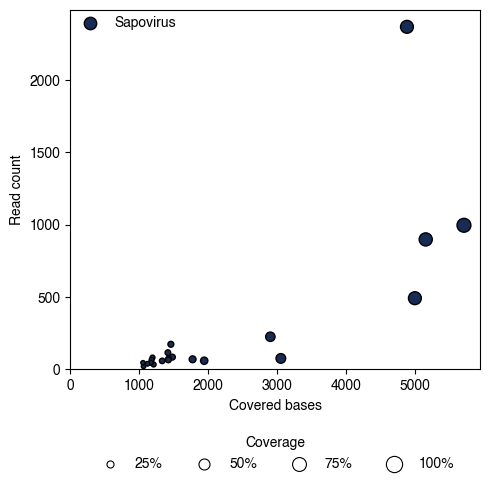

In [68]:

colors = [ '#182b55', '#5f4e94',  '#a291c7',  '#900c3f', '#82cbec',  '#d94f21','#febd2b', '#9aab4b', "#8C92AC","#9b2226", "#6a4c93", "#1982c4",  "#8ac926","#ff595e", "#FFFDD0", "#ffca3a",  "#8338ec", "#3a86ff",]
sapo = sapo.copy()
sapo["Cov_perc"] = sapo["covered_bases"] / sapo["Asm_length"] * 100

plot_df = sapo[(sapo["covered_bases"] >= 0) &(sapo["read_count"] >= 0)].copy()

min_size = 10
max_size = 100
cov_min = plot_df["Cov_perc"].min()
cov_max = plot_df["Cov_perc"].max()

plot_df["dot_size"] = min_size + ((plot_df["Cov_perc"] - cov_min) / (cov_max - cov_min)) * (max_size - min_size)

names = sorted(plot_df["Name"].dropna().unique())

name_colors = {name: colors[i % len(colors)] for i, name in enumerate(names)}

fig, ax = plt.subplots(figsize=(5, 5))

for name in names:
    sub = plot_df[plot_df["Name"] == name]

    ax.scatter(sub["covered_bases"], sub["read_count"],s=sub["dot_size"],color=name_colors[name],edgecolor="black",linewidth=1,alpha=1,label=name)

ax.set_xlabel("Covered bases")
ax.set_ylabel("Read count")

ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

colour_handles = [ ax.scatter([], [], s=80,color=name_colors[name],edgecolor="black", linewidth=1, alpha=1, label=name ) for name in names]

colour_legend = ax.legend( handles=colour_handles,title="",frameon=False,loc="upper left",bbox_to_anchor=(0, 1), borderaxespad=0)

ax.add_artist(colour_legend)

legend_vals = [25, 50, 75, 100]

size_handles = [ ax.scatter( [], [],s=min_size + ((v - cov_min) / (cov_max - cov_min)) * (max_size - min_size), color="white", edgecolor="black",linewidth=0.8,alpha=1,label=f"{v}%" ) for v in legend_vals]

ax.legend(handles=size_handles,title="Coverage",
    frameon=False, loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=len(size_handles))

plt.tight_layout()
plt.show()

In [96]:
len(sapo["sample_ID"].unique())

11

In [69]:
print(sapo["read_count"].min())
print(sapo["read_count"].max())

print(sapo["covered_bases"].min())
print(sapo["covered_bases"].max())

print(sapo["Cov_perc"].min())
print(sapo["Cov_perc"].max())

19
2370
1054
5706
14.132475194422097
75.13826705293653


In [70]:
sapo_grouped = sapo.groupby([ "subspecies"], as_index=False).size().rename(columns={"size": "count"})
sapo_grouped.sort_values("count", ascending=False)

,subspecies,count
2,t__Sapovirus GI.2,7
4,t__Sapovirus Hu/Ehime643/March 2000/JP,4
6,t__Sapovirus Mc10,4
1,t__Sapovirus GI,2
0,t__Nongkhai virus,1
3,t__Sapovirus GIV.1,1
5,t__Sapovirus Hu/OH08021/2008/JP,1
7,t__Sapporo virus,1


In [71]:
MT["Canal"]=[re.sub("MBD", "MB", x.split("_")[0]) for x in MT["sample_ID"]]

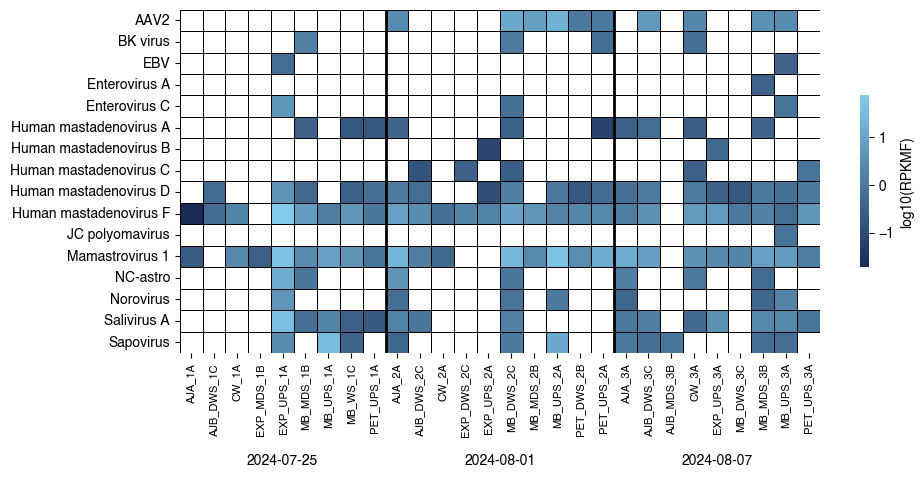

In [72]:
plot_df = MT.copy()
plot_df["log_RPKMF"] = np.log10(plot_df["RPKMF"] + 1e-6)
plot_df["dates"] = plot_df["sample_ID"].str.replace("_", "").map(dates)
plot_df["dates"] = pd.to_datetime(plot_df["dates"])
plot_df["sample_ID"] = plot_df["sample_ID"].str.replace(r"^MBD_", "MB_", regex=True)
assert plot_df["dates"].notna().all(), "unmapped sample_IDs: " + str(
    plot_df.loc[plot_df["dates"].isna(), "sample_ID"].unique()
)

date_by_sample = plot_df.dropna(subset=["sample_ID", "dates"]).groupby("sample_ID")["dates"].min().reset_index().sort_values(["dates", "sample_ID"]).set_index("sample_ID")["dates"]
sample_order = date_by_sample.index.tolist()
ordered_dates = date_by_sample.tolist()

heatmap_df = plot_df.pivot_table(index="Name",columns="sample_ID",values="log_RPKMF",aggfunc="mean").reindex(columns=sample_order).sort_index()

cmap = LinearSegmentedColormap.from_list("custom_blue_yellow", ["#182b55", "#82cbec"])

plt.figure(figsize=(10, 5))
ax = sns.heatmap(heatmap_df,cmap=cmap,linewidths=0.5,linecolor="black",cbar_kws={"label": "log10(RPKMF)", "shrink": 0.5})

groups, start = [], 0
for i in range(1, len(ordered_dates) + 1):
    if i == len(ordered_dates) or ordered_dates[i] != ordered_dates[start]:
        groups.append((start, i, ordered_dates[start]))
        start = i

for s, _, _ in groups[1:]:
    ax.axvline(s, color="black", lw=2)

sec = ax.secondary_xaxis(location=-0.28)
sec.set_xticks(
    [(s + e) / 2 for s, e, _ in groups],
    labels=[d.strftime("%Y-%m-%d") for _, _, d in groups],
)
sec.tick_params(length=0)
sec.spines["bottom"].set_visible(False)

plt.xlabel("")
plt.ylabel("")
plt.xticks(rotation=90, size=8)
plt.yticks(rotation=0)
plt.tight_layout()


plt.show()

In [74]:
from scipy.stats import kruskal, friedmanchisquare, page_trend_test, chi2_contingency
from statsmodels.stats.multitest import multipletests
rng = np.random.default_rng(0)
df = pd.read_csv("temporal_trend.csv")
df["dates"] = pd.to_datetime(df["dates"])
df["tp"] = df["dates"].rank(method="dense").astype(int)          
smeta = df.groupby("sample_ID").agg( tp=("tp", "first"), canal=("canal", "first"),depth=("total_reads", "first"), richness=("Name", "nunique"))
print(smeta.groupby("tp")[["depth", "richness"]].median())

fam = df.groupby(["sample_ID", "family"])["RPKMF"].sum().unstack(fill_value=0.0)
fam = np.log10(fam + 1e-6)
long = fam.stack().rename("log_RPKMF").reset_index().merge(smeta.reset_index()[["sample_ID", "tp", "canal"]], on="sample_ID")
long["det"] = (long["log_RPKMF"] > np.log10(1e-6)).astype(int)

blocks = long.pivot_table(index=["family", "canal"], columns="tp",values="log_RPKMF", aggfunc="mean")

rows = []
for f, g in long.groupby("family"):
    by_tp = [v["log_RPKMF"].values for _, v in g.groupby("tp")]
    b = blocks.loc[f].dropna()
    p_kw = kruskal(*by_tp).pvalue                          
    if len(b) >= 3 and np.unique(b.values).size > 1:
        p_fr = friedmanchisquare(*[b[c].values for c in b.columns]).pvalue   
        p_pg = page_trend_test(b.values, ranked=False).pvalue                
    else:
        p_fr = p_pg = np.nan

    rows.append(dict(family=f, n_det=int(g["det"].sum()), n_blocks=len(b), med_t1=np.median(by_tp[0]), med_t2=np.median(by_tp[1]), med_t3=np.median(by_tp[2]),p_kruskal=p_kw, p_friedman=p_fr, p_page=p_pg))

res = pd.DataFrame(rows)
testable = res["n_det"] >= 5         
for c in ["p_kruskal", "p_friedman", "p_page"]:
    res["q" + c[1:]] = np.nan
    m = testable & res[c].notna()
    res.loc[m, "q" + c[1:]] = multipletests(res.loc[m, c], method="fdr_bh")[1]


def perm_p(det, tp, n=20000):
    def stat(labels):
        t = np.array([[np.sum((labels == k) & (det == 0)),
                       np.sum((labels == k) & (det == 1))] for k in (1, 2, 3)])
        with np.errstate(all="ignore"):
            try:
                return chi2_contingency(t.astype(float))[0]
            except ValueError:
                return 0.0
    s0 = stat(tp)
    null = np.array([stat(rng.permutation(tp)) for _ in range(n)])
    return (1 + np.sum(null >= s0 - 1e-12)) / (n + 1)

pres = []
for f, g in long.groupby("family"):
    g = g.sort_values("sample_ID")
    counts = g.groupby("tp")["det"].agg(["sum", "size"])
    pres.append(dict(family=f,
                     t1=f"{counts.loc[1,'sum']}/{counts.loc[1,'size']}",
                     t2=f"{counts.loc[2,'sum']}/{counts.loc[2,'size']}",
                     t3=f"{counts.loc[3,'sum']}/{counts.loc[3,'size']}",
                     p_detect=perm_p(g["det"].values, g["tp"].values)))
pres = pd.DataFrame(pres)
pres["q_detect"] = multipletests(pres["p_detect"], method="fdr_bh")[1]

print(res.sort_values("p_kruskal").round(3).to_string(index=False))
print(pres.sort_values("p_detect").round(3).to_string(index=False))

        depth  richness
tp                     
1   6449401.0       4.0
2   7211455.5       4.5
3   7107365.0       7.0
            family  n_det  n_blocks  med_t1  med_t2  med_t3  p_kruskal  p_friedman  p_page  q_kruskal  q_friedman  q_page
      Parvoviridae     10         6  -6.000   0.033  -6.000      0.027       0.174   0.160      0.163       0.521   0.319
    Picornaviridae     15         6  -0.657  -6.000   0.261      0.121       0.119   0.100      0.364       0.521   0.319
Orthoherpesviridae      2         6  -6.000  -6.000  -6.000      0.561       0.607   0.558        NaN         NaN     NaN
      Adenoviridae     26         6   0.249   0.664   0.727      0.695       0.311   0.160      0.885       0.623   0.319
     Caliciviridae     11         6  -6.000  -6.000  -0.026      0.713       0.607   0.337      0.885       0.728   0.404
      Astroviridae     24         6   0.734   1.052   0.981      0.772       0.513   0.337      0.885       0.728   0.404
    Polyomaviridae      5 